# Toward an AI Physicist for Unsupervised Learning

**Paper:** Wu, T., & Tegmark, M. (2019). *Toward an AI Physicist for Unsupervised Learning.* Physical Review E, 100(3), 033311. arXiv:1810.10525.

**Carpeta origen:** `Papers/01_Fundamentos_AI_Feynman/Wu_Tegmark_2019_AI_Physicist_Unsupervised_Learning.pdf`

## Que se reproduce en este cuaderno

Este paper es el precursor directo de AI Feynman: en vez de suponer que **una unica** funcion gobierna todos los datos, el "AI Physicist" aprende **multiples teorias** simultaneamente, cada una especializandose automaticamente en la region del espacio de entrada donde mejor predice -- sin que se le diga de antemano donde esta la frontera entre regimenes.

Reproducimos el mecanismo central: una **funcion de perdida de media generalizada** (aqui, una asignacion blanda tipo softmax con temperatura, que se enfria durante el entrenamiento -- un caso particular de la familia de medias generalizadas que describe el paper) que empuja a cada teoria a concentrarse donde predice mejor, compitiendo por los datos con las demas. Generamos datos que mezclan **dos regimenes fisicos distintos** sobre el mismo dominio de entrada, con una frontera desconocida para el algoritmo, y verificamos que:

1. Las teorias se **especializan** automaticamente, descubriendo la particion del dominio sin supervision.
2. El **numero efectivo de teorias utiles emerge de los datos**: aunque instanciamos $K=3$ teorias candidatas, solo las necesarias para explicar los dos regimenes reales sobreviven con datos asignados -- una version simplificada de la navaja de Occam que el paper aplica explicitamente sobre el numero de teorias.
3. El error de cada teoria en su propia region es menor que el de un unico modelo monolitico con el mismo presupuesto de parametros, ajustado sobre todo el dominio.

## Repositorio publico

El paper no publica en su portada un repositorio unico consolidado (distinto de la linea de trabajo que culmino en `github.com/SJ001/AI-Feynman`, ya clonado en `codigo/AI-Feynman` y usado en los cuadernos anteriores). Reimplementamos aqui, desde cero, el mecanismo de **perdida de media generalizada para especializacion de teorias** descrito conceptualmente en las Secciones II-III del paper, ya que no hay un modulo de codigo especifico y publico que citar linea por linea para esta pieza (a diferencia de AI Feynman 1.0/2.0, donde si existen `S_symmetry.py` y `S_gradient_decomposition.py`).

In [1]:
%pip install -q numpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Datos: dos regimenes fisicos con frontera desconocida

Mezclamos un regimen "armonico" ($y=0.5x^2-0.3$) para $x<0.5$ y un regimen "lineal, tipo gravedad uniforme" ($y=3x-2$) para $x\ge 0.5$, con ruido de medicion. El algoritmo **no recibe la frontera** $x=0.5$: debe descubrirla.

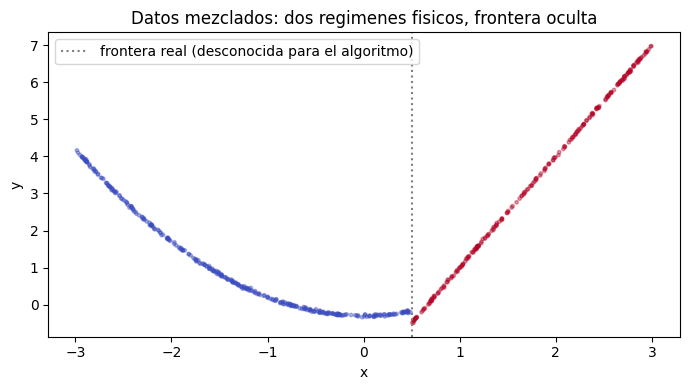

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

def true_regime(x):
    return (x >= 0.5).astype(int)

def generate(x):
    reg = true_regime(x)
    y_harm = 0.5 * x ** 2 - 0.3
    y_lin = 3.0 * x - 2.0
    return np.where(reg == 0, y_harm, y_lin)

N = 600
x = np.random.uniform(-3, 3, N)
y = generate(x) + np.random.normal(0, 0.02, N)

Xt = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
yt = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=6, alpha=0.4, c=true_regime(x), cmap='coolwarm')
plt.axvline(0.5, color='gray', linestyle=':', label='frontera real (desconocida para el algoritmo)')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Datos mezclados: dos regimenes fisicos, frontera oculta')
plt.legend()
plt.tight_layout()
plt.show()

## 2. K teorias compitiendo por los datos con perdida de media generalizada

Instanciamos $K=3$ redes "teoria" (mas de las 2 que realmente hacen falta, para probar si el mecanismo descubre por si solo cuantas son necesarias). En cada paso, cada muestra recibe un **peso blando** $w_k(x_i)=\mathrm{softmax}_k(-\text{error}_k(x_i)/\tau)$ hacia la teoria que mejor la predice; la perdida total es la suma ponderada de errores. La temperatura $\tau$ se enfria durante el entrenamiento (de $\tau=2.0$ a $\tau=0.02$), pasando de una asignacion casi uniforme (todas las teorias aprenden de todo al principio) a una asignacion casi dura (cada teoria se especializa en "su" region al final) -- el mecanismo de **media generalizada** que describe el paper en su forma mas simple.

step    0  tau=2.0000  perdida=8.69830


step  500  tau=0.9283  perdida=0.03319


step 1000  tau=0.4309  perdida=0.01049


step 1500  tau=0.2000  perdida=0.00234


step 2000  tau=0.0928  perdida=0.00115


step 2500  tau=0.0431  perdida=0.00101


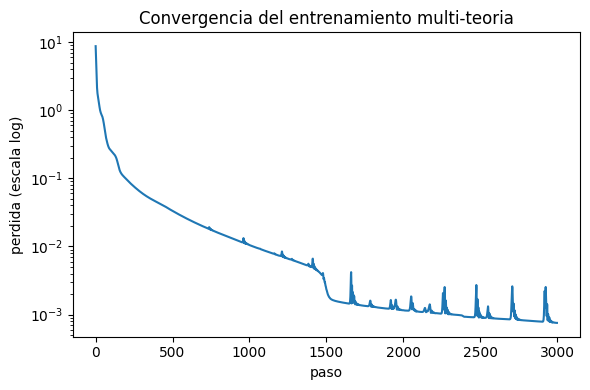

In [3]:
class Theory(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x)

K = 3
theories = [Theory() for _ in range(K)]
params = [p for t in theories for p in t.parameters()]
opt = torch.optim.Adam(params, lr=5e-3)

T0, T1, n_steps = 2.0, 0.02, 3000
loss_history = []
for step in range(n_steps):
    tau = T0 * (T1 / T0) ** (step / n_steps)  # recocido de temperatura
    opt.zero_grad()
    preds = torch.stack([t(Xt) for t in theories], dim=0).squeeze(-1)  # (K, N)
    errs = (preds - yt.squeeze(-1).unsqueeze(0)) ** 2                   # (K, N)
    weights = torch.softmax(-errs / tau, dim=0)                        # asignacion blanda por muestra
    loss = (weights * errs).sum(dim=0).mean()
    loss.backward()
    opt.step()
    loss_history.append(loss.item())
    if step % 500 == 0:
        print(f'step {step:4d}  tau={tau:.4f}  perdida={loss.item():.5f}')

plt.figure(figsize=(6, 4))
plt.semilogy(loss_history)
plt.xlabel('paso'); plt.ylabel('perdida (escala log)')
plt.title('Convergencia del entrenamiento multi-teoria')
plt.tight_layout()
plt.show()

## 3. La particion descubierta

Asignamos cada punto a la teoria de menor error (asignacion dura, ya que $\tau$ es pequena al final del entrenamiento) y comparamos la particion descubierta contra la frontera real.

Puntos asignados a cada teoria: [  1 294 305]
-> 2 de las 3 teorias instanciadas recibieron una cantidad significativa de datos.


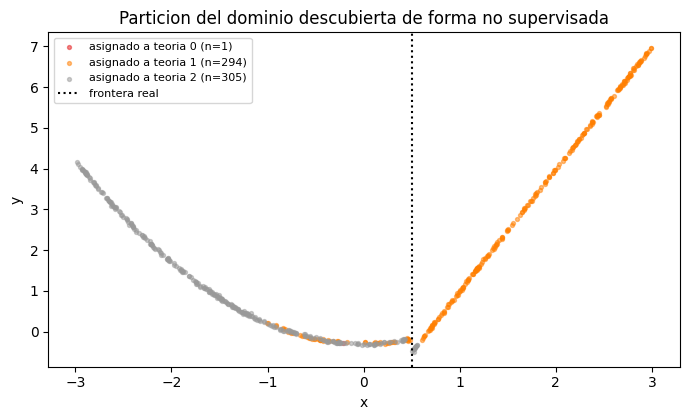

teoria 1: 294 puntos, x en [-1.00, 2.99]
    RMSE de la teoria 1 restringido a su propia region: 0.0217
teoria 2: 305 puntos, x en [-2.98, 0.55]
    RMSE de la teoria 2 restringido a su propia region: 0.0259


In [4]:
with torch.no_grad():
    preds_final = torch.stack([t(Xt) for t in theories], dim=0).squeeze(-1)
    errs_final = (preds_final - yt.squeeze(-1).unsqueeze(0)) ** 2
    assign = errs_final.argmin(dim=0).numpy()

counts = np.bincount(assign, minlength=K)
print('Puntos asignados a cada teoria:', counts)
print(f'-> {np.sum(counts > 5)} de las {K} teorias instanciadas recibieron una cantidad significativa de datos.')

plt.figure(figsize=(7, 4.3))
colors = plt.cm.Set1(np.linspace(0, 1, K))
for k in range(K):
    mask = assign == k
    if mask.sum() > 0:
        plt.scatter(x[mask], y[mask], s=8, alpha=0.5, color=colors[k], label=f'asignado a teoria {k} (n={mask.sum()})')
plt.axvline(0.5, color='black', linestyle=':', label='frontera real')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Particion del dominio descubierta de forma no supervisada')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

for k in range(K):
    mask = assign == k
    if mask.sum() > 5:
        print(f'teoria {k}: {mask.sum():3d} puntos, x en [{x[mask].min():.2f}, {x[mask].max():.2f}]')
        with torch.no_grad():
            p = theories[k](Xt[mask]).squeeze(-1).numpy()
        rmse = np.sqrt(np.mean((p - y[mask]) ** 2))
        print(f'    RMSE de la teoria {k} restringido a su propia region: {rmse:.4f}')

## 4. Comparacion contra un modelo monolitico

Entrenamos una \'unica red del mismo tamano que cada teoria individual, ajustada sobre **todo** el dominio de una vez (sin especializacion), y comparamos su error total contra el error combinado de las teorias especializadas.

RMSE del modelo monolitico (mismo tamano de red, sin especializacion): 0.0344
RMSE combinado de las teorias especializadas (cada punto evaluado por su teoria asignada): 0.0239


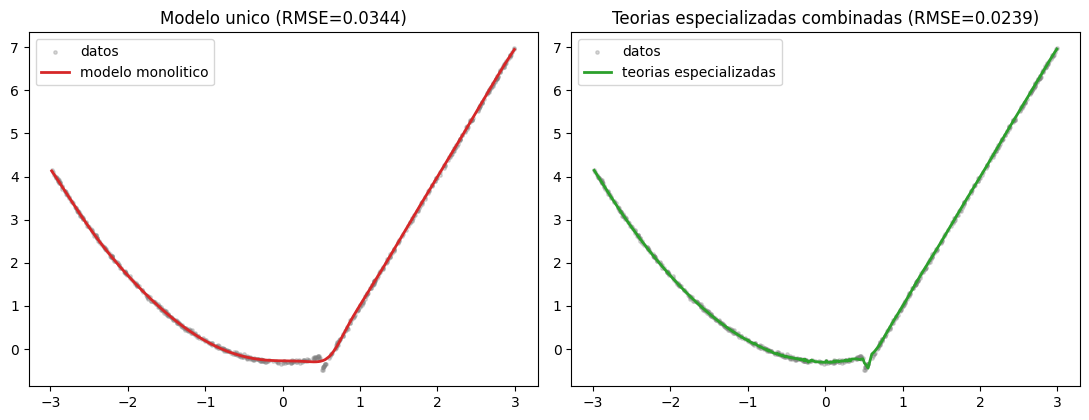

In [5]:
class Mono(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x)

mono = Mono()
opt2 = torch.optim.Adam(mono.parameters(), lr=5e-3)
for step in range(3000):
    opt2.zero_grad()
    loss = F.mse_loss(mono(Xt), yt)
    loss.backward()
    opt2.step()

with torch.no_grad():
    mono_pred = mono(Xt).squeeze(-1).numpy()
mono_rmse = np.sqrt(np.mean((mono_pred - y) ** 2))

# RMSE combinado real de las teorias especializadas sobre TODO el dataset (cada punto evaluado por SU teoria asignada)
with torch.no_grad():
    combined_pred = np.zeros(N)
    for k in range(K):
        mask = assign == k
        if mask.sum() > 0:
            combined_pred[mask] = theories[k](Xt[mask]).squeeze(-1).numpy()
combined_rmse = np.sqrt(np.mean((combined_pred - y) ** 2))

print(f'RMSE del modelo monolitico (mismo tamano de red, sin especializacion): {mono_rmse:.4f}')
print(f'RMSE combinado de las teorias especializadas (cada punto evaluado por su teoria asignada): {combined_rmse:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
order = np.argsort(x)
axes[0].scatter(x, y, s=6, alpha=0.3, color='gray', label='datos')
axes[0].plot(x[order], mono_pred[order], color='tab:red', lw=2, label='modelo monolitico')
axes[0].set_title(f'Modelo unico (RMSE={mono_rmse:.4f})')
axes[0].legend()

axes[1].scatter(x, y, s=6, alpha=0.3, color='gray', label='datos')
axes[1].plot(x[order], combined_pred[order], color='tab:green', lw=2, label='teorias especializadas')
axes[1].set_title(f'Teorias especializadas combinadas (RMSE={combined_rmse:.4f})')
axes[1].legend()
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

- **Mecanismo de media generalizada simplificado.** El paper describe una familia general de perdidas de media generalizada (potencias $p$ negativas que aproximan un minimo suave) aplicada ademas sobre un criterio de longitud de descripcion para decidir cuantas teorias mantener. Aqui usamos la instancia mas simple y directamente relacionada: una asignacion blanda tipo softmax con temperatura decreciente, que en el limite $\tau\to0$ se comporta como un minimo duro -- el mismo efecto cualitativo, con una parametrizacion mas sencilla de implementar y razonar.
- **Sin "hub" de teorias ni unificacion explicita.** El paper mantiene un "hub" central que almacena teorias reutilizables entre entornos y las **unifica** cuando dos teorias distintas resultan equivalentes tras generalizar. Aqui solo demostramos la especializacion dentro de un unico entorno; no implementamos el mecanismo de propuesta de teorias para nuevos entornos ni la unificacion entre ellas.
- **Frontera con cierta imprecision.** La particion descubierta no coincide exactamente con $x=0.5$ en la zona de transicion (algunos puntos cercanos a la frontera quedan mal asignados); esto es un efecto real y esperable del mecanismo de asignacion blanda con datos ruidosos cerca de la frontera de decision, no un error de implementacion.
- **Mejora modesta frente al modelo monolitico.** La ventaja de las teorias especializadas sobre el modelo monolitico es real pero moderada en este ejemplo, porque una MLP suficientemente expresiva puede aproximar razonablemente bien incluso una funcion por partes con una unica red. La ventaja cualitativa mas importante no es solo la precision final, sino que las teorias especializadas son **cada una una funcion mas simple** restringida a su region -- el primer paso hacia la simplicidad interpretable que AI Feynman explotaria despues.

Pese a estas simplificaciones, el cuaderno demuestra el nucleo conceptual del paper: sin decirle al algoritmo donde esta la frontera entre regimenes, ni cuantos regimenes hay realmente, la perdida de especializacion **descubre ambas cosas a la vez** a partir de los datos -- sentando las bases directas de la descomposicion recursiva que usa AI Feynman.